# 伯努利分布

In [3]:
from numpy.random import binomial

p = 0.7
n = 1000
success = binomial(n, p)
print('Total Success: %d' % success)

Total Success: 690


# 二项分布

In [4]:
from scipy.stats import binom

p = 0.6
n = 100
mean, var, s, k = binom.stats(n, p, moments='mvsk')
print(f'均值: {mean:.3f}, 方差: {var:.3f}, 偏度: {s:.3f}, 峰度: {k:.3f}')

均值: 60.000, 方差: 24.000, 偏度: -0.041, 峰度: -0.018


In [5]:
from scipy.stats import binom

p = 0.6
n = 100
dist = binom(n, p)

for k in range(10, 110, 10):
    print(f'100次实验中中{k}个成功的概率是: {dist.pmf(k)*100:.3f}')


100次实验中中10个成功的概率是: 0.000
100次实验中中20个成功的概率是: 0.000
100次实验中中30个成功的概率是: 0.000
100次实验中中40个成功的概率是: 0.002
100次实验中中50个成功的概率是: 1.034
100次实验中中60个成功的概率是: 8.122
100次实验中中70个成功的概率是: 1.001
100次实验中中80个成功的概率是: 0.001
100次实验中中90个成功的概率是: 0.000
100次实验中中100个成功的概率是: 0.000


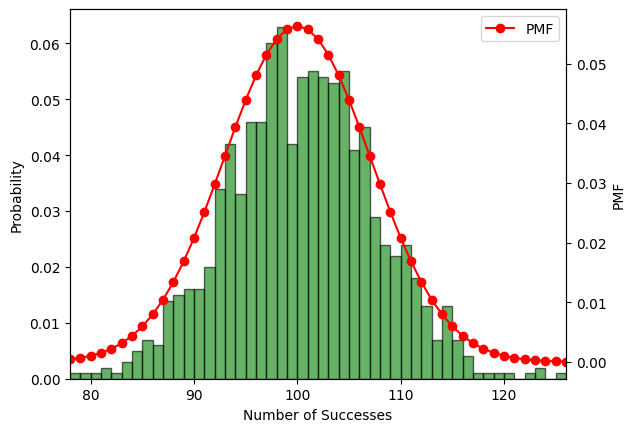

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

n = 200
p = 0.5
size = 1000

binomial_data = np.random.binomial(n, p, size)

fig, ax1 = plt.subplots()

ax1.hist(binomial_data, bins=range(min(binomial_data), max(binomial_data) + 1), density=True, alpha=0.6, color='g', edgecolor='black')
ax1.set_xlabel('Number of Successes')
ax1.set_ylabel('Probability')

ax2 = ax1.twinx()

# PMF
k = np.arange(0, n + 1)
pmf_data = binom.pmf(k, n, p)

ax2.plot(k, pmf_data, 'ro-', label='PMF')
ax2.set_ylabel('PMF')

plt.legend()

plt.xlim(min(binomial_data), max(binomial_data))

plt.show()

# 多项伯努利分布

In [7]:
# example of simulating a multinomial process
from numpy.random import multinomial

p = [1/3, 1/3, 1/3]
n = 100
cases = multinomial(n, p)
for i in range(len(cases)):
    print('x%d: %d' % (i+1, cases[i]))

x1: 31
x2: 37
x3: 32


# 多项分布

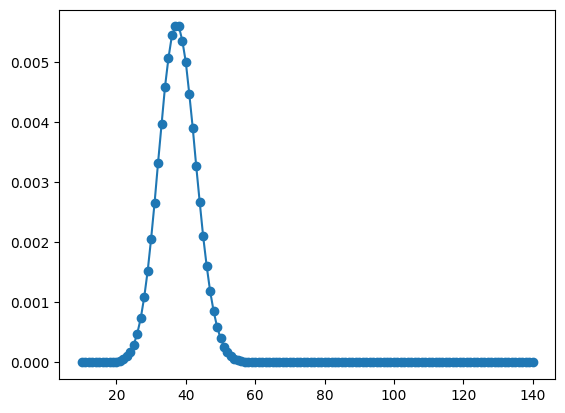

In [10]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multinomial

n = 150
p = [1/4, (1-1/4)/2, (1-1/4)/2]

start = 10
end = n-start

cases = np.array([[i, math.floor((n-i)/2), math.ceil((n-i)/2)] for i in range(start, end + 1)])
probabilities = multinomial.pmf(cases, n, p)

plt.plot(cases[:,0], probabilities, 'o-')
plt.show()

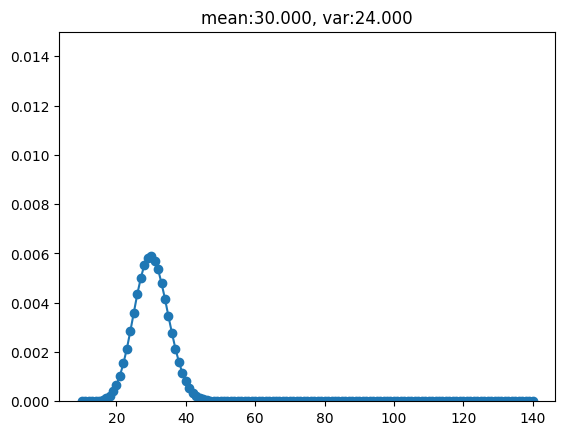

In [1]:
import math
import numpy as np
from scipy.stats import multinomial

import matplotlib.animation
import matplotlib.pyplot as plt


plt.rcParams["animation.html"] = "jshtml"
plt.ioff()
fig, ax = plt.subplots()

n = 150

start = 0.2
end = 0.8
frames = 7
step = (end-start) / (frames-1)

ct_start = 10
ct_end = n-ct_start

def animate(t):
    plt.cla()
    p1 = start + step * t

    p = [p1, (1-p1)/2, (1-p1)/2]

    mean = n * p1
    var = n * p1 * (1-p1)

    plt.title(f'mean:{mean:.3f}, var:{var:.3f}')

    cases = np.array([[i, math.floor((n-i)/2), math.ceil((n-i)/2)] for i in range(ct_start, ct_end + 1)])
    probabilities = multinomial.pmf(cases, n, p)

    plt.plot(cases[:,0], probabilities, 'o-')
    plt.ylim(0, 0.015)

matplotlib.animation.FuncAnimation(fig, animate, frames=frames)